In [40]:
import ipywidgets as widgets
from IPython.display import display

In [41]:
import serial
import serial.tools.list_ports
import json
from datetime import datetime
import ipywidgets as widgets
from IPython.display import display
import pandas as pd
import os

# -------------------------
# Cargar datos existentes
# -------------------------
datos = []

if os.path.exists("datos_celda.json"):
    with open("datos_celda.json") as f:
        for i, linea in enumerate(f):
            linea = linea.strip()
            
            if not linea:
                continue
            
            try:
                datos.append(json.loads(linea))
            except Exception as e:
                print(f"Error en línea {i}: {linea}")
                print(e)

# Crear DataFrame correctamente
df = pd.DataFrame(datos) if datos else pd.DataFrame(columns=["Peso", "lectura", "Hora"])

# -------------------------
# Función para listar puertos
# -------------------------
def listar_puertos():
    puertos = serial.tools.list_ports.comports()
    return [p.device for p in puertos]

# -------------------------
# Widgets
# -------------------------

puertos_dropdown = widgets.Text(
    value='/dev/ttyUSB0',   # puedes cambiarlo
    description='Puerto:'
)

peso_input = widgets.FloatText(
    description='Peso (g):'
)

boton_conectar = widgets.Button(description="Conectar")
boton_guardar = widgets.Button(description="Guardar dato")

salida = widgets.Output()

display(puertos_dropdown, peso_input, boton_conectar, boton_guardar, salida)

# -------------------------
# Variables globales
# -------------------------
ser = None

# -------------------------
# Conectar serial
# -------------------------
def conectar(b):
    global ser
    with salida:
        salida.clear_output()
        try:
            ser = serial.Serial(puertos_dropdown.value, 115200, timeout=1)
            print(f"Conectado a {puertos_dropdown.value}")
        except Exception as e:
            print("Error:", e)

boton_conectar.on_click(conectar)

# -------------------------
# Guardar dato
# -------------------------
def guardar(b):
    global ser, df
    
    with salida:
        salida.clear_output()
        
        if ser is None:
            print("Primero conecta el puerto")
            return
        
        try:
            # -------------------------
            # Leer último dato del buffer
            # -------------------------
            linea = ""
            while ser.in_waiting:
                linea = ser.readline().decode(errors='ignore').strip()
            
            if linea == "":
                print("No se recibió dato")
                return
            
            print("RAW:", linea)  # debug
            
            lectura = float(linea) +85+270
            peso = float(peso_input.value)+85+270
            
            dato = {
                "Peso": peso,
                "lectura": lectura,
                "Hora": datetime.now().isoformat()
            }
            
            # -------------------------
            # Guardar en archivo (NDJSON)
            # -------------------------
            with open("datos_celda.json", "a") as f:
                json.dump(dato, f)
                f.write("\n")
            
            # -------------------------
            # Agregar a DataFrame
            # -------------------------
            df = pd.concat([df, pd.DataFrame([dato])], ignore_index=True)
            
            print("Guardado:", dato)
            display(df.tail())
        
        except Exception as e:
            print("Error:", e)

boton_guardar.on_click(guardar)

Text(value='/dev/ttyUSB0', description='Puerto:')

FloatText(value=0.0, description='Peso (g):')

Button(description='Conectar', style=ButtonStyle())

Button(description='Guardar dato', style=ButtonStyle())

Output()

In [42]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 261 entries, 0 to 260
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Peso     261 non-null    float64
 1   lectura  261 non-null    float64
 2   Hora     261 non-null    str    
dtypes: float64(2), str(1)
memory usage: 6.2 KB


In [43]:
!pip install matplotlib

=== Datos agrupados ===


,Peso,lectura_mean,lectura_std,count
0,355.0,32474.714286,93.416884,21
1,2275.0,-14579.750000,113.507651,20
2,4342.0,-64474.900000,186.567019,20
3,6425.0,-114956.600000,84.636934,20
4,8263.0,-159718.600000,104.952320,20
5,10324.0,-210271.800000,235.529102,20
6,12415.0,-261253.000000,397.719684,20
7,14422.0,-310439.350000,385.471041,20
8,16490.0,-361708.600000,428.749884,20
9,18477.0,-410683.450000,425.462903,20



Regresión: lectura = -24.495680 * Peso + 42028.622955
Std total: 184598.483308


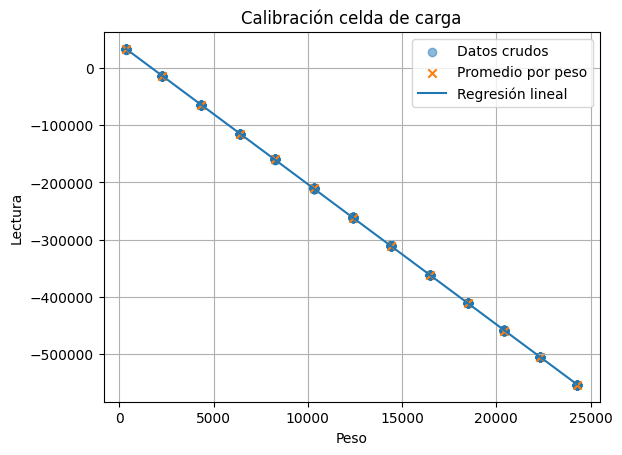

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

if df.empty:
    print("No hay datos")
else:
    # -------------------------
    # AGRUPACIÓN POR PESO
    # -------------------------
    df_group = df.groupby("Peso").agg(
        lectura_mean=("lectura", "mean"),
        lectura_std=("lectura", "std"),
        count=("lectura", "count")
    ).reset_index()

    print("=== Datos agrupados ===")
    display(df_group)

    # -------------------------
    # REGRESIÓN LINEAL
    # -------------------------
    x = df_group["Peso"].values
    y = df_group["lectura_mean"].values

    coef = np.polyfit(x, y, 1)  # grado 1
    pendiente, intercepto = coef

    print(f"\nRegresión: lectura = {pendiente:.6f} * Peso + {intercepto:.6f}")

    # -------------------------
    # VARIANZA GLOBAL
    # -------------------------
    std_total = df["lectura"].std()
    print(f"Std total: {std_total:.6f}")

    # -------------------------
    # RECTA PARA GRAFICAR
    # -------------------------
    x_fit = np.linspace(min(x), max(x), 100)
    y_fit = pendiente * x_fit + intercepto

    # -------------------------
    # GRÁFICA
    # -------------------------
    plt.figure()

    # Datos crudos
    plt.scatter(df["Peso"], df["lectura"], label="Datos crudos", alpha=0.5)

    # Promedios por peso
    plt.scatter(x, y, marker='x', label="Promedio por peso")

    # Recta de regresión
    plt.plot(x_fit, y_fit, label="Regresión lineal")

    plt.xlabel("Peso")
    plt.ylabel("Lectura")
    plt.title("Calibración celda de carga")
    plt.legend()
    plt.grid()

    plt.show()
    #-24570

In [45]:
!which python

/home/elreyrt/Documents/Calibracion_pai/venv/bin/python
